In [1]:
from google.colab import drive
drive.mount('/content/drive')
# !pip install openpyxl==3.0.0    # upgrade from version 2

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import random
import multiprocessing as mp
import dill
import progressbar
import datetime

%load_ext autoreload
%autoreload 2

# !pip uninstall geopandas
!pip install pandas fiona shapely pyproj rtree
!pip install geopandas
import pandas as pd
import geopandas as gpd
import rtree
from shapely.geometry import Point, Polygon
root_path = '/content/drive/'
shapedata_path = root_path + 'MyDrive/Distributionpaper/ShapefileData/'
welldata_path = root_path + 'MyDrive/Distributionpaper/WellData/'
result_path = root_path + 'MyDrive/Distributionpaper/results/'

Mounted at /content/drive
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 16.7 MB 27.6 MB/s 
     |████████████████████████████████| 6.3 MB 56.0 MB/s 
     |████████████████████████████████| 1.0 MB 71.0 MB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.0 MB 36.1 MB/s 


In [2]:
Permian2019Campaign = gpd.GeoDataFrame.from_file(shapedata_path + 'Permian_2019.shp')
PermianFall2021Campaign = gpd.GeoDataFrame.from_file(shapedata_path + 'Permian_fall2021.shp')
PermianFall2021Campaign['CampaignID'] = 1
PermianFall2021SingleShape = PermianFall2021Campaign.dissolve(by='CampaignID', aggfunc='first')
# Permian2019Campaign, PermianFall2021Campaign

In [ ]:
PermianFall2021SingleShape

,geometry,OBJECTID,flightline,date,datetime,platform,campaign,Shape_Leng,Shape_Area
CampaignID,,,,,,,,,
1,"MULTIPOLYGON (((-104.03332 31.65391, -104.0328...",1,GAO20211003t155009p0000,2021-10-03,2021-10-03T15:50:09Z,gao,Permian_fall2021,1.453565,0.017819


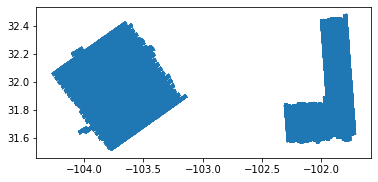

In [3]:
PermianFall2021SingleShape = PermianFall2021Campaign.dissolve(by='CampaignID', aggfunc='first')
Permian2019WithinFall2021 = gpd.tools.sjoin(PermianFall2021SingleShape, Permian2019Campaign, predicate='contains', how='inner')
Permian2019WithinFall2021
Permian2019WithinFall2021.plot()

In [ ]:
# Load CM detections as data frame
def cvt_point_to_geodf(df,latname='lat',lonname='lon'):
    df['coords'] = list(zip(df[lonname],df[latname]))
    df['coords'] = df['coords'].apply(Point)
    gdf = gpd.GeoDataFrame(df, geometry='coords')
    return gdf

CM_2019_2021_plumes = pd.read_excel(root_path + 'MyDrive/Distributionpaper/CalMethaneData/' + 'CarbonMapperPlumeSourceLists_2019-2021.xlsx', sheet_name='Plume_List')
key_cols = CM_2019_2021_plumes.columns
# CM_2019_2021_plumes['count'] = 1
CM_2019_2021_plumes['Year'] = CM_2019_2021_plumes["date_of_detection"].dt.year
CM_2019_2021_plumes = cvt_point_to_geodf(CM_2019_2021_plumes, lonname='plume_lon', latname='plume_lat')
# CM_2019_2021_plumes.shape

(6756, 12)

In [ ]:
# Create Permian 2021 shapefile
PermianFall2021Campaign = gpd.GeoDataFrame.from_file(shapedata_path + 'Permian_fall2021.shp')
PermianFall2021Campaign['CampaignID'] = 1
PermianFall2021SingleShape = PermianFall2021Campaign.dissolve(by='CampaignID', aggfunc='first')

In [ ]:
# CM_2019_2021_plumes['2019_in_F21_area'] = 
InPermianF21Shape = gpd.tools.sjoin(PermianFall2021SingleShape, CM_2019_2021_plumes[CM_2019_2021_plumes['Year']==2019])
InPermianF21Shape = InPermianF21Shape[key_cols]
InPermianF21Shape
InPermianF21Shape.to_csv(result_path + 'CarbonMapperPlumeList_Permian2019_in_F2021.csv')

In [ ]:
# InPermianF21Shape.head()


,geometry,OBJECTID,flightline,date,datetime,platform,campaign,Shape_Leng,Shape_Area,index_right,...,plume_lon,candidate_id,date_of_detection,time_of_detection,source_type,ipcc,qplume,sigma_qplume,count,Year
CampaignID,,,,,,,,,,,,,,,,,,,,,
1,"MULTIPOLYGON (((-104.03332 31.65391, -104.0328...",1,GAO20211003t155009p0000,2021-10-03,2021-10-03T15:50:09Z,gao,Permian_fall2021,1.453565,0.017819,803,...,-101.88963,ang20190924t172057-C,2019-09-24,17:20:57,tank,1B2 Oil & Natural Gas,358.756095,114.396825,1,2019
1,"MULTIPOLYGON (((-104.03332 31.65391, -104.0328...",1,GAO20211003t155009p0000,2021-10-03,2021-10-03T15:50:09Z,gao,Permian_fall2021,1.453565,0.017819,1722,...,-101.85659,ang20191018t172239-A,2019-10-18,17:22:39,well,1B2 Oil & Natural Gas,136.066325,68.447823,1,2019
1,"MULTIPOLYGON (((-104.03332 31.65391, -104.0328...",1,GAO20211003t155009p0000,2021-10-03,2021-10-03T15:50:09Z,gao,Permian_fall2021,1.453565,0.017819,1192,...,-101.85661,ang20191008t160209-A,2019-10-08,16:02:09,well,1B2 Oil & Natural Gas,623.088814,220.101682,1,2019
1,"MULTIPOLYGON (((-104.03332 31.65391, -104.0328...",1,GAO20211003t155009p0000,2021-10-03,2021-10-03T15:50:09Z,gao,Permian_fall2021,1.453565,0.017819,1708,...,-101.86501,ang20191018t150906-B,2019-10-18,15:09:06,tank,1B2 Oil & Natural Gas,580.340621,317.930005,1,2019
1,"MULTIPOLYGON (((-104.03332 31.65391, -104.0328...",1,GAO20211003t155009p0000,2021-10-03,2021-10-03T15:50:09Z,gao,Permian_fall2021,1.453565,0.017819,951,...,-101.92958,ang20191005t221554-A,2019-10-05,22:15:54,processing,1B2 Oil & Natural Gas,5065.505620,1157.778840,1,2019
